In [1]:
import numpy as np
import pandas as pd

In [1]:
import pandas as pd
import io

path = "/Users/ds39/Documents/Sunny/MAVE/RD_projects/concentration/Updated_CellCounts_masterfiles.csv"

# 1) Read as text and swap the two-character sequence "\t" for a real tab
with open(path, "r", encoding="utf-16") as f:
    text = f.read().replace("\\t", "\t")

# 2) Parse from the in-memory string
df = pd.read_csv(io.StringIO(text), sep="\t")

print(df.head())



  HDR Vector Name Date Maveqc Pass Fail  Gini Coefficient  Total Reads  \
0     AJQR_hdr635  19/12/2024      Pass             0.254     22330044   
1     AJQR_hdr635  19/12/2024      Pass             0.255     23455332   
2     AMSJ_hdr394  17/05/2024      Fail             0.264     34729639   
3     AMSJ_hdr394  17/05/2024      Fail             0.266     20254938   
4     AMSJ_hdr394  28/05/2024      Fail             0.261     28704190   

   Accepted Reads  % Reference Reads  % PAM Reads  % Unmapped Reads  \
0      17999453.0                0.1          6.1              31.1   
1      18393476.0                0.1          6.3              29.8   
2      30339549.0                0.8          7.3              47.9   
3      17550748.0                0.8          7.2              49.0   
4      25739119.0                0.7          6.0              56.7   

   % Library Reads  % Correct Size Insert  Library Coverage  Library Size  \
0             62.6                   95.6          

In [2]:
df

,HDR Vector Name,Date Maveqc,Pass Fail,Gini Coefficient,Total Reads,Accepted Reads,% Reference Reads,% PAM Reads,% Unmapped Reads,% Library Reads,% Correct Size Insert,Library Coverage,Library Size,% Missing Library Sequence,Evidence For Contamination
0,AJQR_hdr635,19/12/2024,Pass,0.254,22330044,17999453.0,0.1,6.1,31.1,62.6,95.6,5216.0,2160.0,0.1,No
1,AJQR_hdr635,19/12/2024,Pass,0.255,23455332,18393476.0,0.1,6.3,29.8,63.8,97.9,5434.0,2160.0,0.1,No
2,AMSJ_hdr394,17/05/2024,Fail,0.264,34729639,30339549.0,0.8,7.3,47.9,44.0,86.1,10964.0,1216.0,0.0,No
3,AMSJ_hdr394,17/05/2024,Fail,0.266,20254938,17550748.0,0.8,7.2,49.0,43.0,85.6,6206.0,1216.0,0.0,No
4,AMSJ_hdr394,28/05/2024,Fail,0.261,28704190,25739119.0,0.7,6.0,56.7,36.6,80.1,7756.0,1216.0,0.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,ZZNI_hdr406,17/05/2024,Fail,0.350,30079133,23564878.0,0.5,11.6,50.8,37.0,77.2,4273.0,2040.0,0.0,No
319,ZZNI_hdr406,28/05/2024,Fail,0.344,23335488,18048125.0,0.6,12.2,48.4,38.8,77.8,3435.0,2040.0,0.0,No
320,ZZNI_hdr406,04/06/2024,Fail,0.189,31622530,24512665.0,0.0,6.2,28.1,65.7,82.3,7889.0,2040.0,0.0,No
321,ZZNI_hdr406,04/06/2024,Fail,0.401,36689772,29599030.0,0.4,14.5,52.5,32.5,77.5,4719.0,2040.0,0.0,No


In [3]:
df['Pass Fail'] = df['Pass Fail'].map({'Pass': 1, 'Fail': 0})

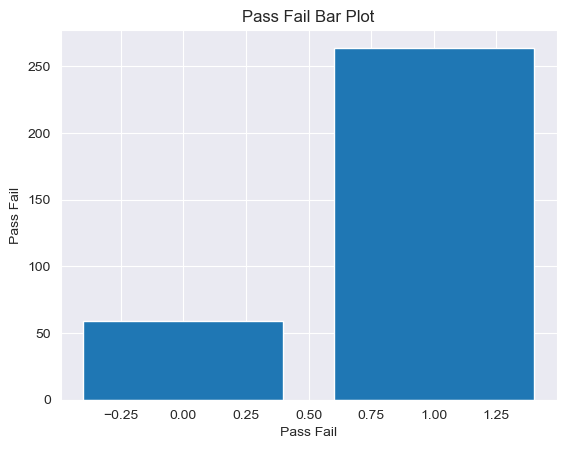

In [4]:
import matplotlib.pyplot as plt

counts = df['Pass Fail'].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.xlabel('Pass Fail')
plt.ylabel('Pass Fail')
plt.title('Pass Fail Bar Plot')
plt.show()


In [14]:
df['Pass Fail']

0      1
1      1
2      0
3      0
4      0
      ..
318    0
319    0
320    0
321    0
322    1
Name: Pass Fail, Length: 323, dtype: int64

# Use a Random Forest with SHAP to compute feature importances and select the top 20 features

In [5]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import shap

# ── 1. LOAD YOUR REAL DATASET ──

cols_to_drop = ['HDR Vector Name', 'Date Maveqc','Evidence For Contamination']  # <-- Replace with actual names
df = df.drop(columns=cols_to_drop)



print("Original columns in df:")
print(df.columns.tolist())

# ── 2. DROP ANY ROWS WITH MISSING VALUES ──
df = df.dropna()
print("\nAfter dropna, columns remain:")
print(df.columns.tolist())

# ── 3. DEFINE FEATURE COLUMNS AND TARGET COLUMN ──
target_col = 'Pass Fail'
feature_names = [col for col in df.columns if col != target_col]

print(f"\nUsing {len(feature_names)} feature columns:")
print(feature_names)

X = df[feature_names]
y = df[target_col]

# ── 4. SPLIT INTO TRAIN/VALID ──
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)

# ── 5. TRAIN THE FULL RANDOM FOREST ──
model_all = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
model_all.fit(X_train, y_train)

# ── 6. CALCULATE SHAP VALUES ──
explainer = shap.TreeExplainer(model_all)
shap_values = explainer.shap_values(X_valid)

# ── 7. MEAN SHAP IMPORTANCE ──
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
feature_importance = list(zip(feature_names, mean_abs_shap))
feature_importance.sort(key=lambda x: x[1], reverse=True)

print("\nTop 10 features by mean(|SHAP|):")
for feat, score in feature_importance[:10]:
    print(f"  {feat:<20} → {score:.4f}")

# ── 8. SELECT TOP FEATURES ──
N = 12
top_features = [f for f, _ in feature_importance[:N]]
print(f"\nTop {N} features: {top_features}")

# ── 9. RETRAIN WITH TOP FEATURES ──
X_train_red = X_train[top_features]
X_valid_red = X_valid[top_features]

model_red = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
model_red.fit(X_train_red, y_train)

# ── 10. EVALUATE ──
y_pred_all = model_all.predict(X_valid)
y_pred_red = model_red.predict(X_valid_red)

r2_all = r2_score(y_valid, y_pred_all)
rmse_all = np.sqrt(mean_squared_error(y_valid, y_pred_all))

r2_red = r2_score(y_valid, y_pred_red)
rmse_red = np.sqrt(mean_squared_error(y_valid, y_pred_red))

print("\nModel performance:")
print(f"  • Full model    → R² = {r2_all:.3f}, RMSE = {rmse_all:.3f}")
print(f"  • Reduced model → R² = {r2_red:.3f}, RMSE = {rmse_red:.3f}")



Original columns in df:
['Pass Fail', 'Gini Coefficient', 'Total Reads', 'Accepted Reads', '% Reference Reads', '% PAM Reads', '% Unmapped Reads', '% Library Reads', '% Correct Size Insert', 'Library Coverage', 'Library Size', '% Missing Library Sequence']

After dropna, columns remain:
['Pass Fail', 'Gini Coefficient', 'Total Reads', 'Accepted Reads', '% Reference Reads', '% PAM Reads', '% Unmapped Reads', '% Library Reads', '% Correct Size Insert', 'Library Coverage', 'Library Size', '% Missing Library Sequence']

Using 11 feature columns:
['Gini Coefficient', 'Total Reads', 'Accepted Reads', '% Reference Reads', '% PAM Reads', '% Unmapped Reads', '% Library Reads', '% Correct Size Insert', 'Library Coverage', 'Library Size', '% Missing Library Sequence']

Top 10 features by mean(|SHAP|):
  % Unmapped Reads     → 0.1255
  % Library Reads      → 0.0667
  % Correct Size Insert → 0.0602
  % Missing Library Sequence → 0.0255
  Library Size         → 0.0054
  Total Reads          → 0.0048

All columns in the dataset:
['Pass Fail', 'Gini Coefficient', 'Total Reads', 'Accepted Reads', '% Reference Reads', '% PAM Reads', '% Unmapped Reads', '% Library Reads', '% Correct Size Insert', 'Library Coverage', 'Library Size', '% Missing Library Sequence']

Using 11 feature columns:
['Gini Coefficient', 'Total Reads', 'Accepted Reads', '% Reference Reads', '% PAM Reads', '% Unmapped Reads', '% Library Reads', '% Correct Size Insert', 'Library Coverage', 'Library Size', '% Missing Library Sequence']

Top 20 features by mean absolute SHAP value:
 1. % Unmapped Reads          → 0.1255
 2. % Library Reads           → 0.0667
 3. % Correct Size Insert     → 0.0602
 4. % Missing Library Sequence → 0.0255
 5. Library Size              → 0.0054
 6. Total Reads               → 0.0048
 7. % PAM Reads               → 0.0036
 8. Gini Coefficient          → 0.0032
 9. Accepted Reads            → 0.0026
10. % Reference Reads         → 0.0020
11. Library Coverage          → 0.0018


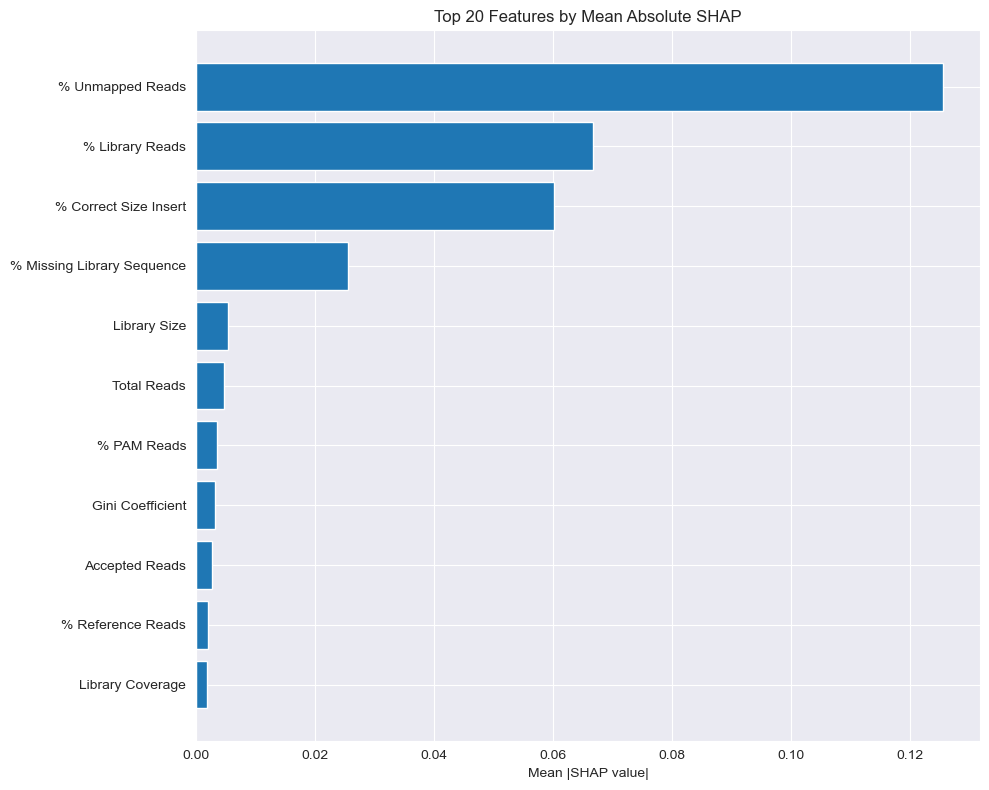

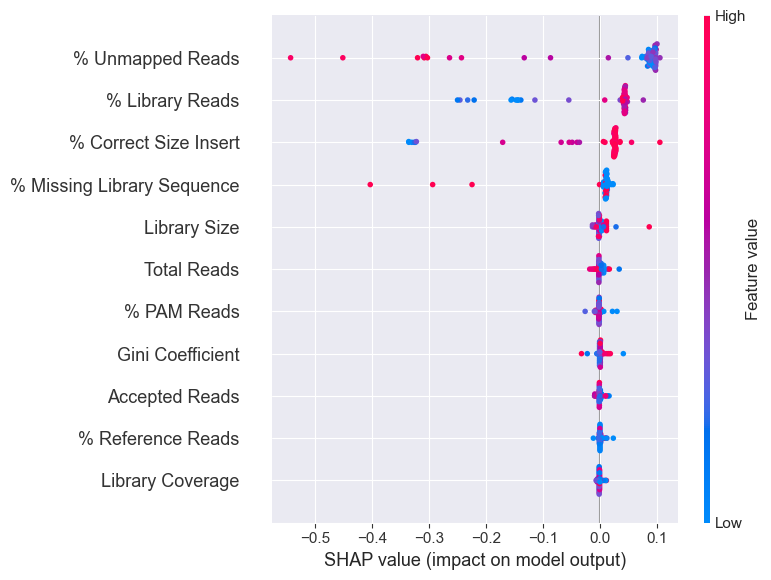

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split



# Print all column names of the dataset
print("All columns in the dataset:")
print(df.columns.tolist())




target_col = 'Pass Fail'
feature_names = [col for col in df.columns if col != target_col]

# Print feature names that will be used
print(f"\nUsing {len(feature_names)} feature columns:")
print(feature_names)

X = df[feature_names]
y = df[target_col]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# ── Fit RandomForest and compute SHAP values ──
model_all = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
model_all.fit(X_train, y_train)

explainer = shap.TreeExplainer(model_all)
shap_values = explainer.shap_values(X_valid)

# ── Compute mean absolute SHAP per feature ──
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
feat_importance = list(zip(feature_names, mean_abs_shap))
feat_importance.sort(key=lambda x: x[1], reverse=True)

# ── Print top 30 features with their SHAP scores ──
top_n = 20
top_feats = feat_importance[:top_n]
print(f"\nTop {top_n} features by mean absolute SHAP value:")
for rank, (name, score) in enumerate(top_feats, start=1):
    print(f"{rank:2d}. {name:<25} → {score:.4f}")

# ── Bar plot: Mean |SHAP| for top 30 features ──
names = [f[0] for f in top_feats][::-1]  # reverse for horizontal bar order
scores = [f[1] for f in top_feats][::-1]

plt.figure(figsize=(10, 8))
plt.barh(names, scores)
plt.xlabel('Mean |SHAP value|')
plt.title(f'Top {top_n} Features by Mean Absolute SHAP')
plt.tight_layout()
plt.show()

# ── SHAP summary plot for all features ──
plt.figure()
shap.summary_plot(shap_values, X_valid, show=True)


# This code implements different ML with 5-fold cross-validation and evaluation on test set

5-fold CV accuracies on TRAINING SET: [0.889 0.956 0.978 0.956 0.955]
Mean (train CV) accuracy = 0.946 ± 0.030

Classification Report on TEST SET:
              precision    recall  f1-score   support

        Fail       0.89      0.94      0.91        17
        Pass       0.99      0.97      0.98        79

    accuracy                           0.97        96
   macro avg       0.94      0.96      0.95        96
weighted avg       0.97      0.97      0.97        96


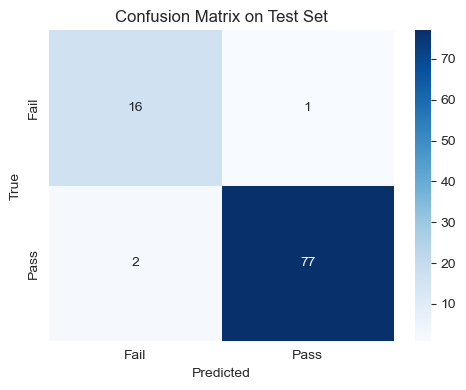

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. LOAD YOUR DATAFRAME ──
# (Assuming df is already loaded and ‘Pass Fail’ has been mapped to 0/1)

# ── 2. DEFINE FEATURES + TARGET ──
selected_features = [
    'Gini Coefficient', 'Total Reads', 'Accepted Reads',
    '% Reference Reads', '% PAM Reads', '% Unmapped Reads',
    '% Library Reads', '% Correct Size Insert',
    'Library Coverage', 'Library Size',
    '% Missing Library Sequence'
]
target_col = 'Pass Fail'

X = df[selected_features]
y = df[target_col].astype(int)  # ensure integer 0/1

# ── 3. SPLIT INTO TRAIN (70%) AND TEST (30%) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=0,
    stratify=y
)

# ── 4. 5-FOLD CV ON TRAINING SET ──
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
clf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)

cv_scores = cross_val_score(
    clf, X_train, y_train,
    cv=skf, scoring='accuracy', n_jobs=-1
)
print("5-fold CV accuracies on TRAINING SET:", np.round(cv_scores, 3))
print(f"Mean (train CV) accuracy = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# ── 5. RETRAIN ON FULL TRAINING SET & EVALUATE ON TEST SET ──
clf_final = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
clf_final.fit(X_train, y_train)
y_pred = clf_final.predict(X_test)

print("\nClassification Report on TEST SET:")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

# ── 6. CONFUSION MATRIX ──
conf_mat = confusion_matrix(y_test, y_pred, labels=[0, 1])
plt.figure(figsize=(5,4))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fail', 'Pass'],
    yticklabels=['Fail', 'Pass']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()



========== KNN (k=5) ==========
5-fold CV accuracies on TRAIN:
   [0.889 0.844 0.756 0.889 0.886]
  Mean = 0.853, Std = 0.051

Classification report on HELD-OUT TEST:
              precision    recall  f1-score   support

        Fail       0.67      0.24      0.35        17
        Pass       0.86      0.97      0.91        79

    accuracy                           0.84        96
   macro avg       0.76      0.60      0.63        96
weighted avg       0.82      0.84      0.81        96


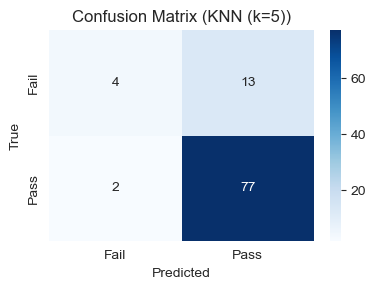


========== SVM (RBF) ==========
5-fold CV accuracies on TRAIN:
   [0.822 0.822 0.822 0.822 0.841]
  Mean = 0.826, Std = 0.007

Classification report on HELD-OUT TEST:
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00        17
        Pass       0.82      1.00      0.90        79

    accuracy                           0.82        96
   macro avg       0.41      0.50      0.45        96
weighted avg       0.68      0.82      0.74        96


/Users/ds39/miniforge3/envs/depimgs/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/ds39/miniforge3/envs/depimgs/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/ds39/miniforge3/envs/depimgs/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le

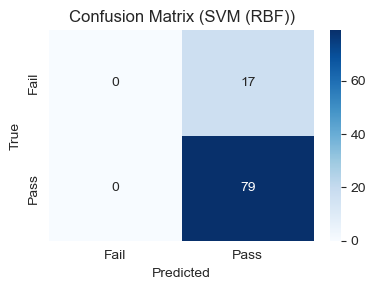


========== Random Forest ==========
5-fold CV accuracies on TRAIN:
   [0.889 0.956 0.978 0.956 0.955]
  Mean = 0.946, Std = 0.030

Classification report on HELD-OUT TEST:
              precision    recall  f1-score   support

        Fail       0.89      0.94      0.91        17
        Pass       0.99      0.97      0.98        79

    accuracy                           0.97        96
   macro avg       0.94      0.96      0.95        96
weighted avg       0.97      0.97      0.97        96


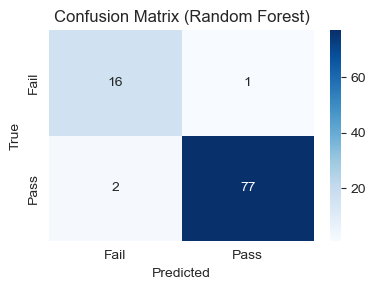


========== Gradient Boosting ==========
5-fold CV accuracies on TRAIN:
   [0.889 0.978 0.933 1.    0.955]
  Mean = 0.951, Std = 0.038

Classification report on HELD-OUT TEST:
              precision    recall  f1-score   support

        Fail       0.88      0.88      0.88        17
        Pass       0.97      0.97      0.97        79

    accuracy                           0.96        96
   macro avg       0.93      0.93      0.93        96
weighted avg       0.96      0.96      0.96        96


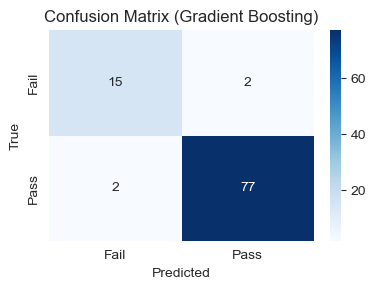


========== Logistic Regression ==========
5-fold CV accuracies on TRAIN:
   [0.844 0.867 0.911 0.844 0.886]
  Mean = 0.871, Std = 0.026

Classification report on HELD-OUT TEST:
              precision    recall  f1-score   support

        Fail       0.60      0.53      0.56        17
        Pass       0.90      0.92      0.91        79

    accuracy                           0.85        96
   macro avg       0.75      0.73      0.74        96
weighted avg       0.85      0.85      0.85        96


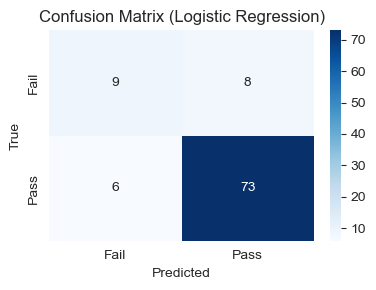

In [12]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns




# ── 5. Split into train (70%) and test (30%) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=0,
    stratify=y
)

# ── 6. Define a small “model zoo” ──
classifiers = {
    'KNN (k=5)'           : KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True, random_state=0),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=0),
    'Logistic Regression' : LogisticRegression(max_iter=500, random_state=0)
}

# ── 7. For each classifier: 5-fold CV on TRAIN, then train & evaluate on TEST ── sunny need to understand the 5-fold 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

for name, clf in classifiers.items():
    print(f"\n========== {name} ==========")

    # 7a. Cross-validated accuracy on TRAINING SET
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf,
                                scoring='accuracy', n_jobs=-1)
    print("5-fold CV accuracies on TRAIN:")
    print("  ", np.round(cv_scores, 3))
    print(f"  Mean = {cv_scores.mean():.3f}, Std = {cv_scores.std():.3f}")

    # 7b. Retrain on full TRAIN and evaluate on TEST
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print("\nClassification report on HELD-OUT TEST:")
    print(classification_report(y_test, y_pred, target_names=['Fail','Pass']))

    # 7c. Plot confusion matrix on TEST
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    plt.figure(figsize=(4,3))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Fail','Pass'],
        yticklabels=['Fail','Pass']
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix ({name})')
    plt.tight_layout()
    plt.show()


# This code implements a simple MLP for binary classification

In [18]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Features and Target ──
features = [
    "Gini Coefficient", "Total Reads", "Accepted Reads",
    "% Reference Reads", "% PAM Reads", "% Unmapped Reads",
    "% Library Reads", "% Correct Size Insert",
    "Library Coverage", "Library Size",
    "% Missing Library Sequence"
]
target_col = "Pass Fail"

# Load your DataFrame `df` beforehand
X = df[features].values.astype(np.float32)
y = df[target_col].values.astype(np.int64)

# ── 2. Stratified Split ──
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=0
)

# ── 3. Balance the Training and Validation Sets ──
def balance_df(X, y):
    df = pd.DataFrame(X, columns=features)
    df['label'] = y
    df_0 = df[df['label'] == 0]
    df_1 = df[df['label'] == 1]
    n = min(len(df_0), len(df_1))
    df_0_bal = resample(df_0, n_samples=n, random_state=0, replace=False)
    df_1_bal = resample(df_1, n_samples=n, random_state=0, replace=False)
    df_bal = pd.concat([df_0_bal, df_1_bal]).sample(frac=1.0, random_state=0)
    return df_bal[features].values.astype(np.float32), df_bal['label'].values.astype(np.int64)

X_train, y_train = balance_df(X_train, y_train)
X_val, y_val = balance_df(X_val, y_val)

# ── 4. Dataloaders ──
batch_size = 16
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

# ── 5. MLP Model ──
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, h1=32, h2=16):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(h2, 2)
        )
    def forward(self, x):
        return self.model(x)

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model = MLPClassifier(input_dim=X_train.shape[1]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ── 6. Training and Evaluation ──
def train_epoch():
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(train_loader.dataset)

def evaluate():
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            p = out.argmax(dim=1).cpu().numpy()
            preds.append(p)
            trues.append(yb.cpu().numpy())
    return np.concatenate(trues), np.concatenate(preds)

def safe_classification_report(y_true, y_pred):
    unique_labels = sorted(set(y_true) | set(y_pred))
    name_map = {0: "Fail", 1: "Pass"}
    labels = unique_labels
    target_names = [name_map[l] for l in labels]
    print(classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0
    ))

# ── 7. Training Loop ──
num_epochs = 30
for epoch in range(1, num_epochs + 1):
    loss = train_epoch()
    y_true, y_pred = evaluate()
    if epoch == 1 or epoch % 5 == 0:
        print(f"\nEpoch {epoch:02d} | Loss: {loss:.4f}")
        safe_classification_report(y_true, y_pred)

# ── 8. Final Evaluation ──
y_true, y_pred = evaluate()
print("\nFinal Classification Report on Validation Set:")
safe_classification_report(y_true, y_pred)

# ── 9. Confusion Matrix ──
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fail", "Pass"], yticklabels=["Fail", "Pass"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MLP Confusion Matrix")
plt.tight_layout()
plt.show()


/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_36825/826393459.py:24: RuntimeWarning: invalid value encountered in cast
  y = df[target_col].values.astype(np.int64)


InvalidParameterError: The 'n_samples' parameter of resample must be an int in the range [1, inf) or None. Got 0 instead.

# This code implements a simple MLP with attention mechanism for binary classification

In [81]:
class TinyMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=4, num_classes=2):
        super().__init__()
        self.attn = nn.Linear(input_dim, input_dim)  # gives one attention weight per feature
        self.fc1  = nn.Linear(input_dim, hidden_dim)
        self.fc2  = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        scores  = self.attn(x)                    # [B, input_dim]
        weights = torch.softmax(scores, dim=1)    # [B, input_dim]
        x_attn  = x * weights                     # [B, input_dim]

        h = self.relu(self.fc1(x_attn))           # [B, hidden_dim]
        h = self.dropout(h)
        out = self.fc2(h)                         # [B, num_classes]
        return out


Epoch 01 | Train Loss: 0.7553 | Train Acc: 0.411 | Val Acc: 0.400
Epoch 05 | Train Loss: 0.7420 | Train Acc: 0.411 | Val Acc: 0.400
Epoch 10 | Train Loss: 0.7282 | Train Acc: 0.411 | Val Acc: 0.400
Epoch 15 | Train Loss: 0.7159 | Train Acc: 0.411 | Val Acc: 0.400
Epoch 20 | Train Loss: 0.7000 | Train Acc: 0.500 | Val Acc: 0.400
Epoch 25 | Train Loss: 0.7012 | Train Acc: 0.446 | Val Acc: 0.480
Epoch 30 | Train Loss: 0.6869 | Train Acc: 0.518 | Val Acc: 0.600


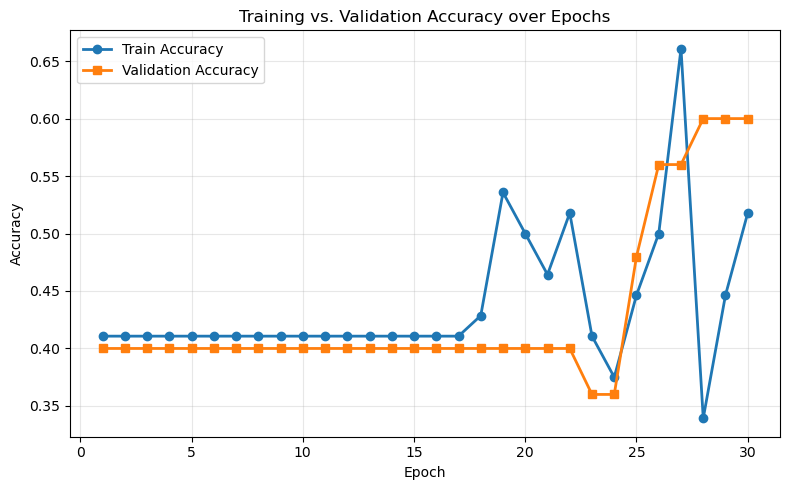

In [87]:
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# ── 1. Load and preprocess dataset ──
import pandas as pd

df = pd.read_csv('/Users/haoranyue/Downloads/finalinhibitor2.csv')
df = df.drop(columns=['molecule', 'SMILES']).dropna()

# ── 2. Define features and binary target ──
def categorize_ic50(value):
    return 0 if value <= 1 else 1  # 0: low, 1: high

df['label'] = df['IC50'].apply(categorize_ic50)

# Choose one of your feature‐lists here:
selected_features = [
    'fr_Al_OH',
    'SMR_VSA10',
    'VSA_EState10',
    'VSA_EState4',
    'fr_bicyclic',
    'BCUT2D_MRLOW',
    'MaxEStateIndex',
    'FpDensityMorgan3',
    'FractionCSP3',
    'fr_COO',
    'SlogP_VSA6',
    'BalabanJ',
    'VSA_EState2',
    'PEOE_VSA4',
    'EState_VSA1',
    'fr_COO2',
    'VSA_EState3',
    'EState_VSA8',
    'PEOE_VSA9',
    'MinAbsEStateIndex',
    'SlogP_VSA7',
    'BCUT2D_MWLOW',
    'MolLogP',
    'fr_Ar_COO',
    'SlogP_VSA4',
    'Ipc',
    'Chi4n',
    'qed',
    'Chi4v',
    'PEOE_VSA11'
]

X = df[selected_features].values.astype(np.float32)
y = df['label'].values.astype(np.int64)

# ── 3. Split into train (70%) / validation (30%) ──
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, random_state=0, stratify=y
)

# ── 4. Create DataLoaders ──
batch_size = 4
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_dataset   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

import torch
import torch.nn.functional as F
from torch import nn

class AttentionMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=4, num_classes=2):
        super().__init__()
        # 1) Compute one attention score per feature (so we can softmax over features)
        self.feature_attention = nn.Linear(input_dim, input_dim)

        # 2) Two-layer MLP:
        #    fc1: input_dim → hidden_dim
        #    fc2: hidden_dim  → num_classes
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

        self.dropout = nn.Dropout(0.5)
        self.relu   = nn.ReLU()

    def forward(self, x):
        # x: [batch_size, num_features]
        # 1) Attention: project each feature, softmax across features, then scale
        attn_scores  = self.feature_attention(x)       # [B, num_features]
        attn_weights = F.softmax(attn_scores, dim=1)   # [B, num_features]
        x_attn       = x * attn_weights                # [B, num_features]

        # 2) Two-layer MLP on the weighted features
        h = self.relu(self.fc1(x_attn))                # [B, hidden_dim]
        h = self.dropout(h)
        out = self.fc2(h)                              # [B, num_classes]
        return out


# ── 6. Instantiate model, loss, optimizer ──
device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
model = AttentionMLP(input_dim=X_train.shape[1]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ── 7. Training loop with accuracy tracking ──
num_epochs = 30

train_accuracies = []   # will store train accuracy per epoch
val_accuracies   = []   # will store val accuracy per epoch

for epoch in range(1, num_epochs + 1):
    # ---- Training step ----
    model.train()
    running_corrects = 0
    running_total    = 0
    total_loss       = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()

        outputs = model(xb)                   # [batch_size, 2]
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(dim=1)         # predicted labels
        running_corrects += (preds == yb).sum().item()
        running_total    += xb.size(0)

    epoch_loss = total_loss / running_total
    train_acc  = running_corrects / running_total
    train_accuracies.append(train_acc)

    # ---- Validation step ----
    model.eval()
    val_running_corrects = 0
    val_running_total    = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1)
            val_running_corrects += (preds == yb).sum().item()
            val_running_total    += xb.size(0)

    val_acc = val_running_corrects / val_running_total
    val_accuracies.append(val_acc)

    # ---- Print every 5 epochs ----
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | Train Loss: {epoch_loss:.4f} | "
              f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")
        # You can also print a quick classification report for validation if you like:
        # (But that slows things down, so usually we print only every 10 epochs or so.)

# ── 8. Plot accuracy curves ──
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o', linewidth=2)
plt.plot(epochs, val_accuracies,   label='Validation Accuracy', marker='s', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy over Epochs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# This code implements a simple GNN  for binary classification

/Users/haoranyue/miniforge3/envs/LLMs/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 01 | Train Loss: 1.9655
              precision    recall  f1-score   support

         low       0.33      0.20      0.25        10
        high       0.58      0.73      0.65        15

    accuracy                           0.52        25
   macro avg       0.46      0.47      0.45        25
weighted avg       0.48      0.52      0.49        25

Epoch 05 | Train Loss: 1.1247
              precision    recall  f1-score   support

         low       0.42      0.80      0.55        10
        high       0.67      0.27      0.38        15

    accuracy                           0.48        25
   macro avg       0.54      0.53      0.47        25
weighted avg       0.57      0.48      0.45        25

Epoch 10 | Train Loss: 0.7328
              precision    recall  f1-score   support

         low       0.22      0.20      0.21        10
        high       0.50      0.53      0.52        15

    accuracy                           0.40        25
   macro avg       0.36      0.37     

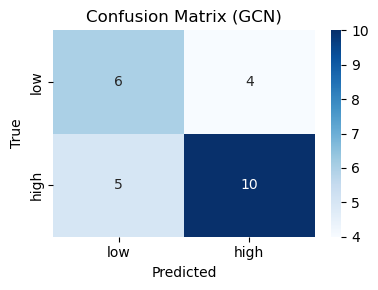

In [90]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch_geometric.data import Data, InMemoryDataset, DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Load and preprocess dataset ──
df = pd.read_csv('/Users/haoranyue/Downloads/finalinhibitor2.csv')
df = df.drop(columns=['molecule', 'SMILES']).dropna()

# ── 2. Define features and binary target ──
selected_features = [
    'SlogP_VSA7', 'fr_Al_OH', 'SMR_VSA10', 'VSA_EState4', 'PEOE_VSA11',
    'MolLogP', 'FractionCSP3', 'PEOE_VSA3', 'BCUT2D_MWHI', 'VSA_EState10',
    'PEOE_VSA6', 'NumRotatableBonds', 'Chi4v', 'VSA_EState2', 'SlogP_VSA3',
    'SlogP_VSA6', 'fr_COO', 'MinAbsPartialCharge', 'BCUT2D_MRLOW', 'PEOE_VSA9',
]


def categorize_ic50(value):
    return 0 if value <= 1 else 1  # 0: low, 1: high


df['label'] = df['IC50'].apply(categorize_ic50)

X = df[selected_features].values.astype(np.float32)
y = df['label'].values.astype(np.int64)

# ── 3. Split into train (70%) / validation (30%) ──
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.30,
    random_state=0,
    stratify=y
)


# ── 4. Build PyG Data objects for each split ──
def build_graph_list(X_array, y_array):
    """
    Given a NumPy array of shape [N, 20] and labels [N], returns a list of PyG Data objects.
    Each Data object has:
      - x: [1, 20]  (one node with 20 features)
      - edge_index: [[0],[0]] (self-loop)
      - y: [1] (label)
    """
    data_list = []
    for i in range(X_array.shape[0]):
        x_i = torch.from_numpy(X_array[i]).view(1, -1)  # [1, 20]
        edge_index = torch.tensor([[0], [0]], dtype=torch.long)  # self-loop
        y_i = torch.tensor([int(y_array[i])], dtype=torch.long)  # [1]
        data_list.append(Data(x=x_i, edge_index=edge_index, y=y_i))
    return data_list


train_graphs = build_graph_list(X_train, y_train)
val_graphs = build_graph_list(X_val, y_val)

batch_size = 16
train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)


# ── 5. Define a small GCN classifier ──
class SingleNodeGCNClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, num_classes: int):
        super().__init__()
        torch.manual_seed(0)
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.lin = nn.Linear(hidden_channels // 2, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x, edge_index, batch):
        # x: [sum_nodes, in_channels]; but here each graph has exactly one node,
        # so sum_nodes = batch_size. edge_index always self-loops per graph.
        h = self.conv1(x, edge_index)  # [sum_nodes, hidden_channels]
        h = self.relu(h)
        h = self.conv2(h, edge_index)  # [sum_nodes, hidden_channels//2]
        h = self.relu(h)
        # Global pool over each graph: since each graph is exactly one node,
        # global_mean_pool just returns that node’s embedding.
        h_graph = global_mean_pool(h, batch)  # [batch_size, hidden_channels//2]
        return self.lin(h_graph)  # [batch_size, num_classes]


device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
model = SingleNodeGCNClassifier(
    in_channels=X_train.shape[1],  # 20 features
    hidden_channels=32,  # you can tune this (32 → 16 → output)
    num_classes=2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# ── 6. Training and evaluation functions ──
def train_one_epoch():
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)  # [batch_size, 2]
        loss = criterion(out, batch.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_graphs)


def evaluate():
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)  # [batch_size, 2]
            preds = out.argmax(dim=1).cpu().numpy()  # [batch_size]
            labels = batch.y.view(-1).cpu().numpy()  # [batch_size]
            all_preds.append(preds)
            all_labels.append(labels)

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return all_labels, all_preds


# ── 7. Training loop ──
num_epochs = 30
for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch()
    y_true, y_pred = evaluate()
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f}")
        print(classification_report(y_true, y_pred, target_names=['low', 'high'], zero_division=0))

# ── 8. Final evaluation ──
y_true, y_pred = evaluate()
print("Final Classification Report on Validation Set:")
print(classification_report(y_true, y_pred, target_names=['low', 'high'], zero_division=0))

# ── 9. Confusion matrix ──
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['low', 'high'], yticklabels=['low', 'high'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (GCN)')
plt.tight_layout()
plt.show()


# # Graph Neural Network for IC50 Prediction using the ranking loss (Learning to ranking)

/Users/haoranyue/miniforge3/envs/LLMs/lib/python3.10/site-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


Epoch 01 | Train Rank Loss: 0.7694 | Val Rank Loss: 0.9406 | Val Acc: 0.546
Epoch 02 | Train Rank Loss: 0.5239 | Val Rank Loss: 0.8242 | Val Acc: 0.658
Epoch 03 | Train Rank Loss: 0.3901 | Val Rank Loss: 0.7560 | Val Acc: 0.669
Epoch 04 | Train Rank Loss: 0.3052 | Val Rank Loss: 0.7822 | Val Acc: 0.669
Epoch 05 | Train Rank Loss: 0.2548 | Val Rank Loss: 0.7792 | Val Acc: 0.665
Epoch 06 | Train Rank Loss: 0.2206 | Val Rank Loss: 0.8609 | Val Acc: 0.665
Epoch 07 | Train Rank Loss: 0.1888 | Val Rank Loss: 0.8487 | Val Acc: 0.690
Epoch 08 | Train Rank Loss: 0.1629 | Val Rank Loss: 0.8894 | Val Acc: 0.690
Epoch 09 | Train Rank Loss: 0.1503 | Val Rank Loss: 0.8973 | Val Acc: 0.708
Epoch 10 | Train Rank Loss: 0.1526 | Val Rank Loss: 0.8949 | Val Acc: 0.701
Epoch 11 | Train Rank Loss: 0.1306 | Val Rank Loss: 0.9237 | Val Acc: 0.708
Epoch 12 | Train Rank Loss: 0.1196 | Val Rank Loss: 0.9254 | Val Acc: 0.708
Epoch 13 | Train Rank Loss: 0.1123 | Val Rank Loss: 0.9546 | Val Acc: 0.701
Epoch 14 | T

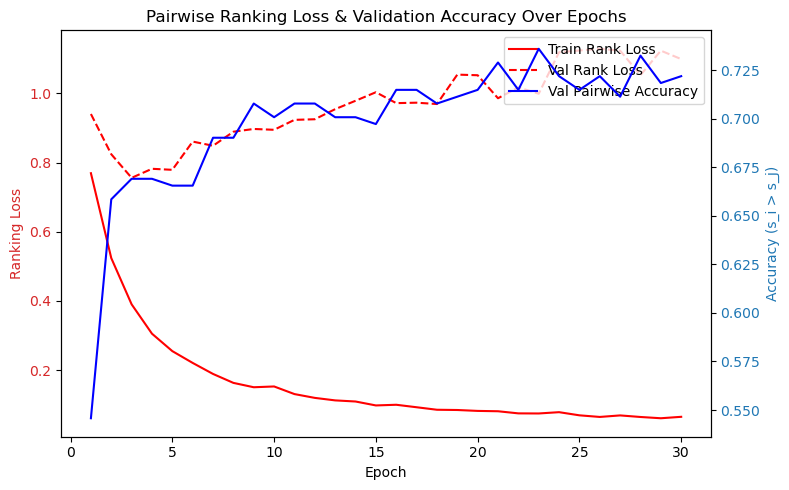

In [39]:
import os
import torch
import pandas as pd
import numpy as np
from torch.nn import Linear
from torch_geometric.data import InMemoryDataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torch.utils.data import random_split, Dataset
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ── 1. Define the 20 selected features ──
selected_features = [
    'SlogP_VSA7', 'fr_Al_OH', 'SMR_VSA10', 'VSA_EState4', 'PEOE_VSA11',
    'MolLogP', 'FractionCSP3', 'PEOE_VSA3', 'BCUT2D_MWHI', 'VSA_EState10',
    'PEOE_VSA6', 'NumRotatableBonds', 'Chi4v', 'VSA_EState2', 'SlogP_VSA3',
    'SlogP_VSA6', 'fr_COO', 'MinAbsPartialCharge', 'BCUT2D_MRLOW', 'PEOE_VSA9'
]

# ── 2. Create a PyG InMemoryDataset where each graph is a single node with those 20 features ──
class SingleNodeIC50Dataset(InMemoryDataset):
    def __init__(self, csv_path, selected_features, transform=None, pre_transform=None):
        super().__init__(os.path.dirname(csv_path), transform, pre_transform)

        df = pd.read_csv(csv_path).dropna()
        df = df.drop(columns=['molecule', 'SMILES'], errors='ignore')

        self.selected_features = selected_features
        target_col = 'IC50'
        df = df[self.selected_features + [target_col]]

        data_list = []
        for _, row in df.iterrows():
            # Build x = [1, 20] tensor from the 20 descriptors
            x = torch.tensor(row[self.selected_features].values, dtype=torch.float).view(1, -1)

            # Build edge_index = self-loop [[0], [0]]
            edge_index = torch.tensor([[0], [0]], dtype=torch.long)

            # Build y = [1] float tensor for IC50
            y = torch.tensor([row[target_col]], dtype=torch.float)

            data_list.append(Data(x=x, edge_index=edge_index, y=y))

        self.data, self.slices = self.collate(data_list)

    def __len__(self):
        return self.data.y.shape[0]


# ── 3. Define the GCN ranker (outputs one scalar score per graph) ──
class GCNRank(torch.nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int):
        super().__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels // 2)
        self.lin   = Linear(hidden_channels // 2, 1)

    def forward(self, x, edge_index, batch):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()
        h_graph = global_mean_pool(h, batch)   # [batch_size, hidden_dim]
        return self.lin(h_graph).view(-1)      # [batch_size]


# ── 4. Revised PairwiseRankingDataset that works with Subsets ──
class PairwiseRankingDataset(Dataset):
    """
    Given an underlying IC50 dataset (or Subset), produce pairs (i,j)
    such that IC50_i + delta < IC50_j.  Each __getitem__ returns (i,j,data_i,data_j).
    """
    def __init__(self, base_dataset, delta: float = 0.1):
        self.base_dataset = base_dataset
        self.delta = delta

        # 1) Extract all IC50 values from base_dataset
        ys = []
        for idx in range(len(base_dataset)):
            ic50_value = base_dataset[idx].y.item()
            ys.append(ic50_value)
        ys = torch.tensor(ys)

        # 2) Build list of all valid (i,j) pairs
        pairs = []
        N = len(ys)
        for i in range(N):
            for j in range(N):
                if ys[i] + self.delta < ys[j]:
                    pairs.append((i, j))
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        i, j = self.pairs[idx]
        data_i = self.base_dataset[i]
        data_j = self.base_dataset[j]
        return i, j, data_i, data_j


# ── 5. Collate function for batching ranking pairs ──
def pairwise_collate(batch):
    """
    batch is a list of (i, j, data_i, data_j). We combine all i-graphs into batch_i,
    all j-graphs into batch_j.  Return idx lists + two batched PyG Batches.
    """
    idx_i = [item[0] for item in batch]
    idx_j = [item[1] for item in batch]
    data_i_list = [item[2] for item in batch]
    data_j_list = [item[3] for item in batch]

    from torch_geometric.data import Batch
    batch_i = Batch.from_data_list(data_i_list)
    batch_j = Batch.from_data_list(data_j_list)

    return idx_i, idx_j, batch_i, batch_j


# ── 6. Put it all together: load dataset, split, build pairwise loaders ──
csv_path = '/Users/haoranyue/Downloads/finalinhibitor2.csv'
dataset = SingleNodeIC50Dataset(csv_path=csv_path, selected_features=selected_features)

if len(dataset) < 5:
    raise RuntimeError("Need at least 5 compounds to form ranking pairs.")

# Split 70% train / 30% val
torch.manual_seed(0)
lengths = [int(0.7 * len(dataset)), len(dataset) - int(0.7 * len(dataset))]
train_base, val_base = random_split(dataset, lengths)

# Build pairwise datasets from those Subsets
train_pairs = PairwiseRankingDataset(train_base, delta=0.1)
val_pairs   = PairwiseRankingDataset(val_base,   delta=0.1)

train_loader = DataLoader(train_pairs, batch_size=32, shuffle=True, collate_fn=pairwise_collate)
val_loader   = DataLoader(val_pairs,   batch_size=32, shuffle=False, collate_fn=pairwise_collate)


# ── 7. Instantiate model, optimizer ──
in_channels = dataset[0].x.size(1)  # = 20
model = GCNRank(in_channels=in_channels, hidden_channels=32)

device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# ── 8. Ranking hinge loss (pairwise) ──
def ranking_loss(scores_i, scores_j, margin=1.0):
    """
    scores_i: torch.Tensor of shape [batch_size], more potent compounds
    scores_j: torch.Tensor of shape [batch_size], less potent ones
    We apply hinge: max(0, margin - (s_i - s_j)).
    """
    diff = scores_i - scores_j
    losses = F.relu(margin - diff)
    return losses.mean()


# ── 9. Training & evaluation loops ──
def train_one_epoch():
    model.train()
    total_loss = 0.0
    for idx_i, idx_j, batch_i, batch_j in train_loader:
        batch_i = batch_i.to(device)
        batch_j = batch_j.to(device)

        optimizer.zero_grad()
        s_i = model(batch_i.x, batch_i.edge_index, batch_i.batch)  # [batch_size]
        s_j = model(batch_j.x, batch_j.edge_index, batch_j.batch)

        loss = ranking_loss(s_i, s_j, margin=1.0)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * s_i.size(0)

    return total_loss / len(train_pairs)


def eval_one_epoch():
    model.eval()
    total_loss = 0.0
    num_correct = 0
    num_pairs = 0

    with torch.no_grad():
        for idx_i, idx_j, batch_i, batch_j in val_loader:
            batch_i = batch_i.to(device)
            batch_j = batch_j.to(device)

            s_i = model(batch_i.x, batch_i.edge_index, batch_i.batch)
            s_j = model(batch_j.x, batch_j.edge_index, batch_j.batch)

            loss = ranking_loss(s_i, s_j, margin=1.0)
            total_loss += loss.item() * s_i.size(0)

            # Count correct orderings
            num_correct += (s_i > s_j).sum().item()
            num_pairs += s_i.size(0)

    avg_loss = total_loss / len(val_pairs)
    accuracy = num_correct / num_pairs if num_pairs > 0 else 0.0
    return avg_loss, accuracy


# ── 10. Run training for 30 epochs and track metrics ──
num_epochs = 30
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(1, num_epochs + 1):
    tloss = train_one_epoch()
    vloss, vacc = eval_one_epoch()

    train_losses.append(tloss)
    val_losses.append(vloss)
    val_accuracies.append(vacc)

    print(f"Epoch {epoch:02d} | Train Rank Loss: {tloss:.4f} | "
          f"Val Rank Loss: {vloss:.4f} | Val Acc: {vacc:.3f}")


# ── 11. Plot pairwise ranking loss & validation accuracy ──
epochs = np.arange(1, num_epochs + 1)

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(epochs, train_losses, 'r-', label='Train Rank Loss')
ax1.plot(epochs, val_losses,   'r--', label='Val Rank Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Ranking Loss', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(epochs, val_accuracies, 'b-', label='Val Pairwise Accuracy')
ax2.set_ylabel('Accuracy (s_i > s_j)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Pairwise Ranking Loss & Validation Accuracy Over Epochs')
plt.tight_layout()
plt.show()





